In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## Recap

In [2]:
def standard_units(arr):
    """ Converts an array to standard units """
    return (arr - np.average(arr))/np.std(arr)

def correlation(t, x, y):
    """ Computes correlation: t is a table, and x and y are column names """
    x_standard = standard_units(t.column(x))
    y_standard = standard_units(t.column(y))
    return np.average(x_standard * y_standard)

def slope(t, x, y):
    """ Computes the slope of the regression line, like correlation above """
    r = correlation(t, x, y)
    y_sd = np.std(t.column(y))
    x_sd = np.std(t.column(x))
    return r * y_sd / x_sd

def intercept(t, x, y):
    """ Computes the intercept of the regression line, like slope above """
    x_mean = np.mean(t.column(x))
    y_mean = np.mean(t.column(y))
    return y_mean - slope(t, x, y)*x_mean

def fitted_values(t, x, y):
    """Return an array of the regression estimates (predictions) at all the x values"""
    a = slope(t, x, y)
    b = intercept(t, x, y)
    return a*t.column(x) + b

_________

In [3]:
demographics = Table.read_table('district_demographics2016.csv')
demographics.sample(6).show()

State,District,Median Income,Percent voting for Clinton,College%
California,"Congressional District 44 (115th Congress), California",50890,83,12.3
New York,"Congressional District 14 (115th Congress), New York",53512,77.7,25.6
New Jersey,"Congressional District 4 (115th Congress), New Jersey",78511,41,39.6
California,"Congressional District 22 (115th Congress), California",56524,42.6,24.1
Texas,"Congressional District 17 (115th Congress), Texas",50888,38.8,29.4
California,"Congressional District 18 (115th Congress), California",125790,73.4,61.5


In [5]:
def local_average_income(college):
    """Return a prediction of Median Income from College%
    by averaging over districts with similar College% values.
    """
    a_little = 2
    close_points = demographics.where('College%', are.between(college - a_little, 
                                                              college + a_little))
    return close_points.column('Median Income').mean()   

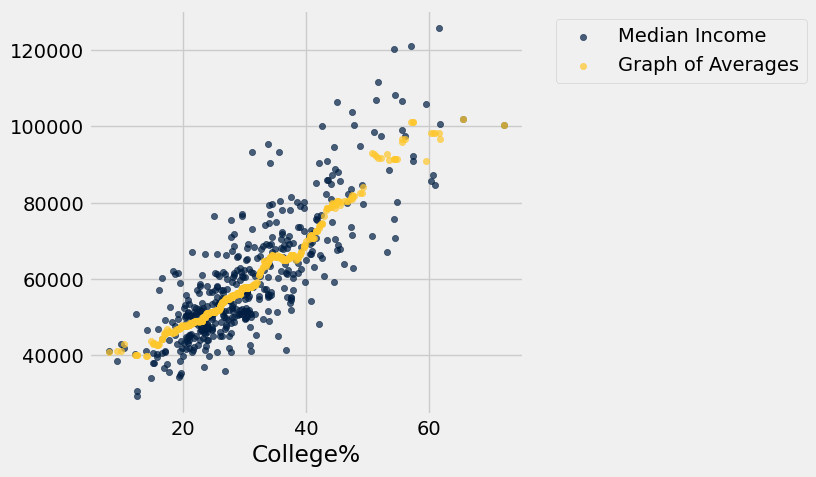

In [6]:
with_averages = demographics.select('College%', 'Median Income').with_columns('Graph of Averages',
    demographics.apply(local_average_income, 'College%'))

with_averages.scatter('College%')

**Linear Fit**

$\text{estimate of Median Income} = a \cdot \text{College\%} + b$

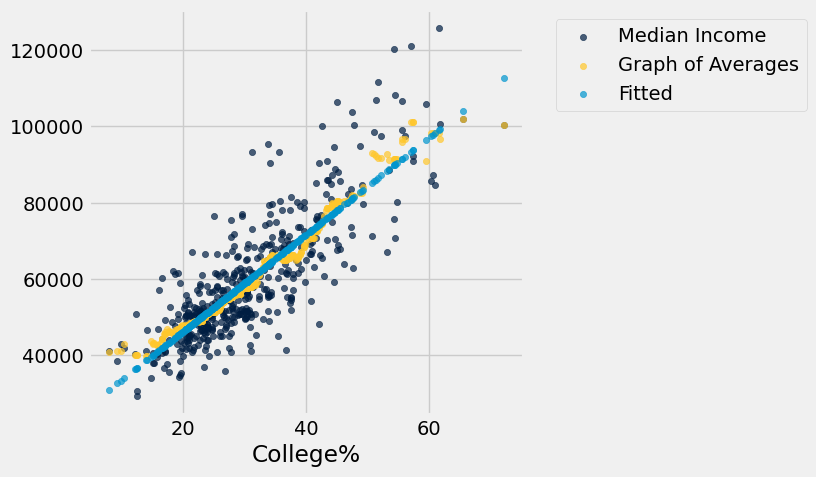

In [7]:
fitted_income = with_averages.with_columns('Fitted',
    fitted_values(demographics, 'College%', 'Median Income'))
fitted_income.scatter('College%')

**STOP**

## New material

In [8]:
def residuals(t, x, y):
    predictions = fitted_values(t, x, y)
    return t.column(y) - predictions

### Residual plots can tell us about our model fit

#### Case study 1: 2016 election demographics

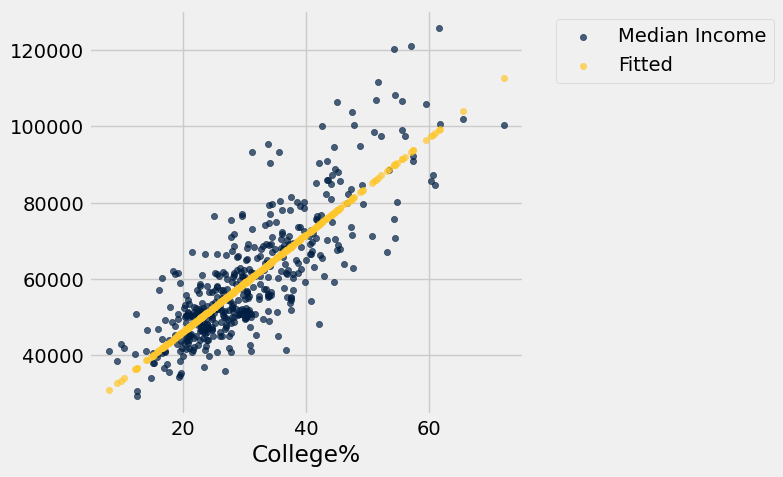

In [9]:
fitted_income = demographics.select('College%', 'Median Income')
fitted_income = fitted_income.with_columns('Fitted',
    fitted_values(demographics, 'College%', 'Median Income'))
fitted_income.scatter('College%')

In [10]:
income_residuals = fitted_income.with_columns(
    'Residual', residuals(demographics, 'College%', 'Median Income')
)
income_residuals.show(5)

College%,Median Income,Fitted,Residual
24,47083,51299.4,-4216.42
21.8,42035,48503.9,-6468.87
22.8,46544,49774.6,-3230.58
17,41110,42404.5,-1294.51
30.3,51690,59304.8,-7614.84


These two functions will help us plot things the rest of the way.

In [11]:
def plot_fitted(t, x, y):
    tbl = t.with_columns('Fitted', fitted_values(t, x, y))
    tbl.select(x, y, 'Fitted').scatter(0)

In [14]:
def plot_residuals(t, x, y):
    tbl = t.with_columns('Residual', residuals(t, x, y))
    tbl.scatter(x, 'Residual')

______

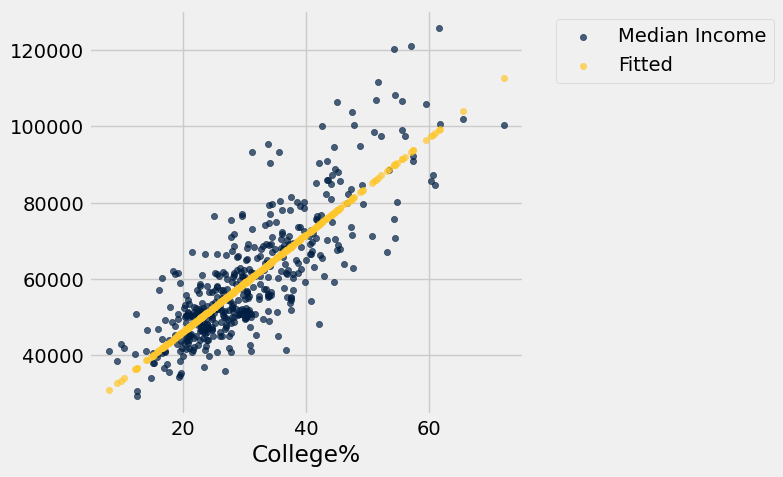

In [13]:
plot_fitted(demographics, 'College%', 'Median Income')

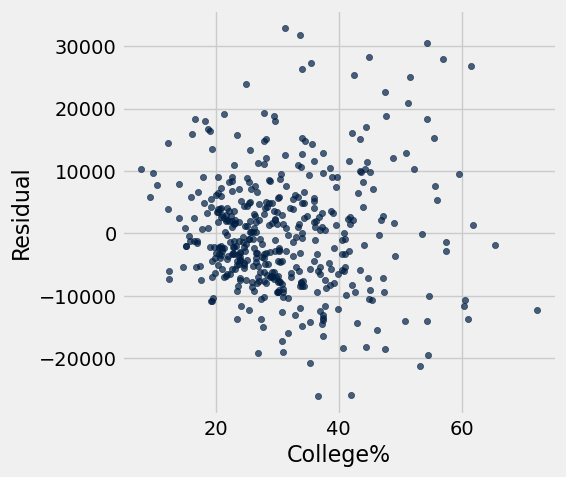

In [15]:
plot_residuals(demographics, 'College%', 'Median Income')

#### Case study 2: dugongs 

In [17]:
dugong = Table.read_table('dugong.csv')
dugong.show(5)

Length,Age
1.8,1
1.85,1.5
1.87,1.5
1.77,1.5
2.02,2.5


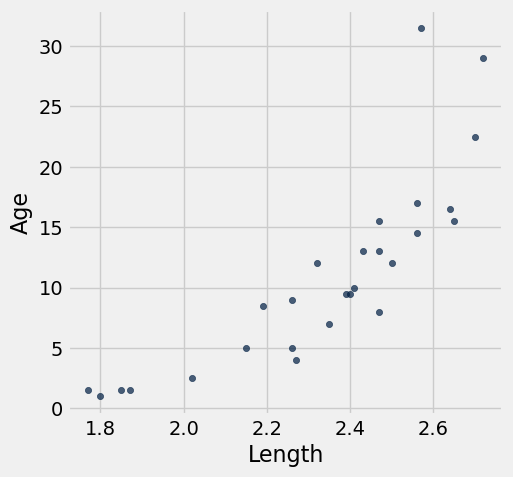

In [18]:
dugong.scatter('Length', 'Age')

In [19]:
correlation(dugong, 'Length', 'Age')

0.82964745549057139

$\text{estimate of Age} = a \cdot \text{Length} + b$

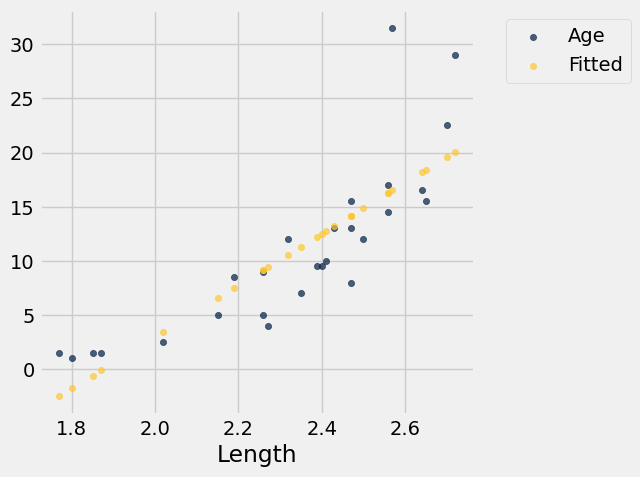

In [20]:
plot_fitted(dugong, 'Length', 'Age')

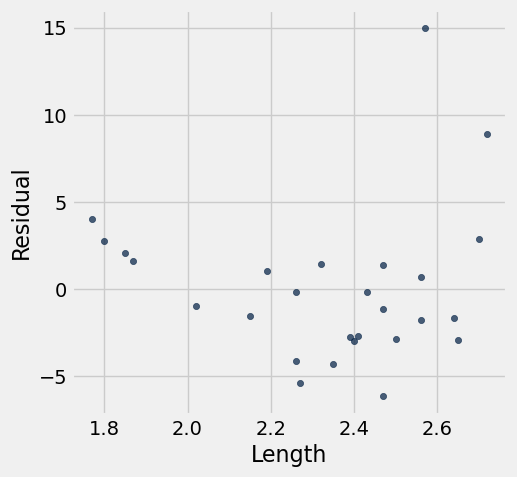

In [21]:
plot_residuals(dugong, 'Length', 'Age')

#### Case study 3: US women

In [22]:
us_women = Table.read_table('us_women.csv')
us_women.show(5)

height,ave weight
58,115
59,117
60,120
61,123
62,126


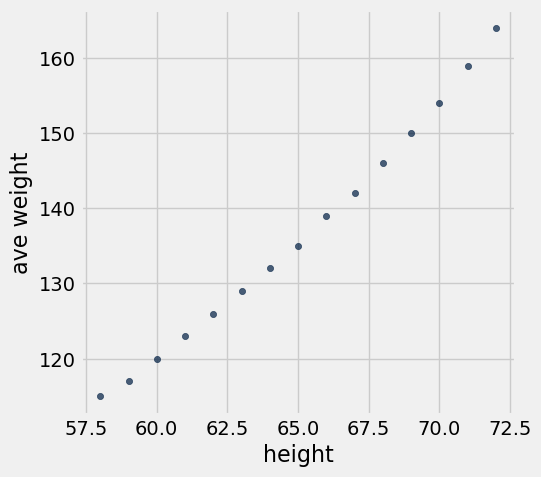

In [23]:
us_women.scatter('height')

In [24]:
correlation(us_women, 'height', 'ave weight')

0.99549476778421608

$\text{estimate of height} = a \cdot \text{average weight} + b$

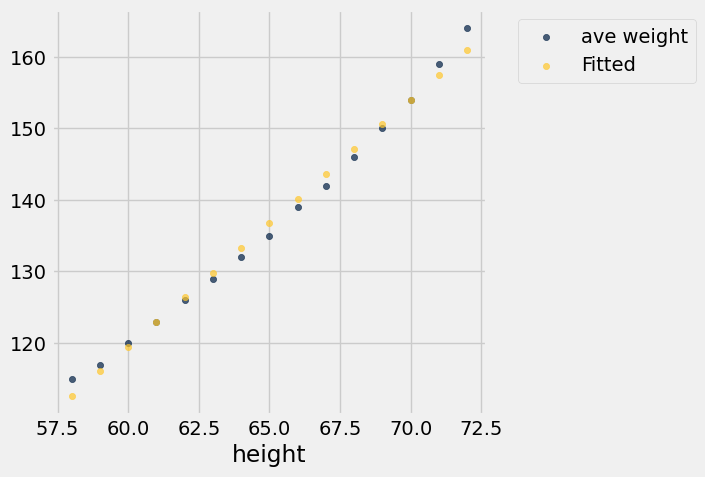

In [25]:
plot_fitted(us_women, 'height', 'ave weight')

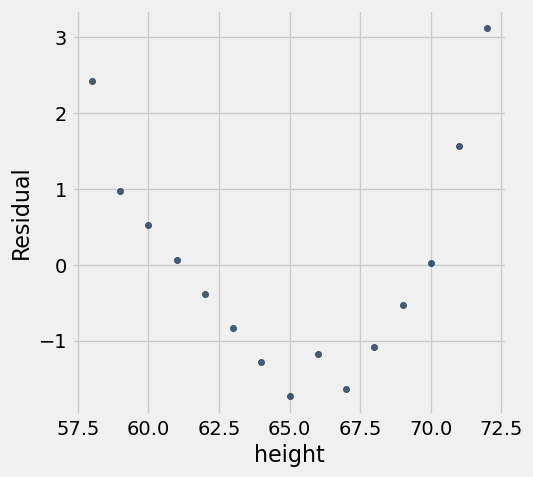

In [26]:
plot_residuals(us_women, 'height', 'ave weight')

#### Case study 4: Heights

In [27]:
family_heights = Table.read_table('family_heights.csv')
family_heights.where('family', '1')

family,father,mother,child,children,order,sex
1,78.5,67,73.2,4,1,male
1,78.5,67,69.2,4,2,female
1,78.5,67,69,4,3,female
1,78.5,67,69,4,4,female


In [28]:
parents = (family_heights.column('father') + family_heights.column('mother'))/2
heights = Table().with_columns(
    'Parent Average', parents,
    'Child', family_heights.column('child')
    )
heights.show(6)

Parent Average,Child
72.75,73.2
72.75,69.2
72.75,69
72.75,69
71,73.5
71,72.5


$\text{estimate of a child's adult height} = a \cdot \text{average parent height} + b$

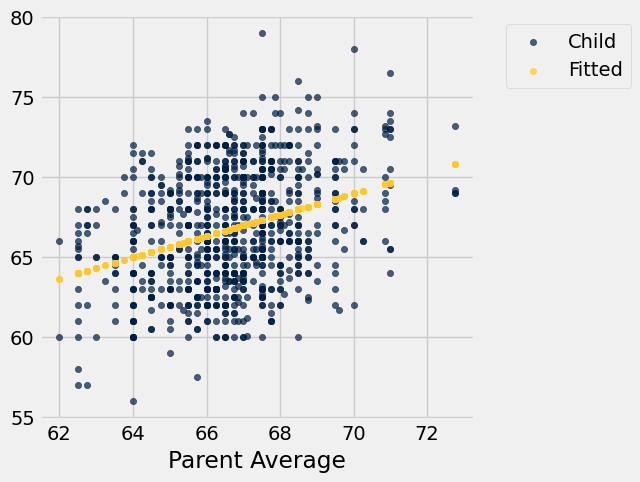

In [29]:
plot_fitted(heights, 'Parent Average', 'Child')

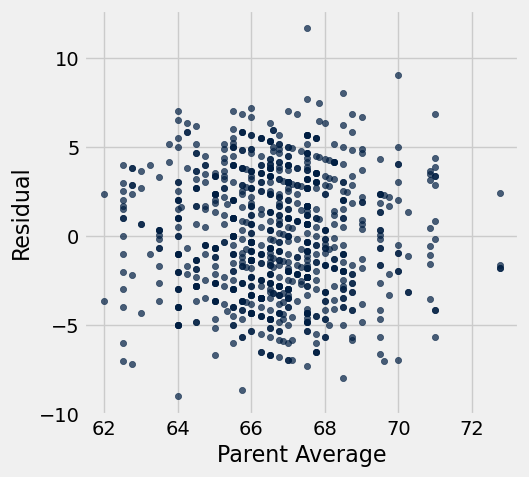

In [30]:
plot_residuals(heights, 'Parent Average', 'Child')

### Residuals have some special properties!

 The average/mean of the residuals are zero.

In [31]:
round(np.average(residuals(demographics, 'College%', 'Median Income')), 10)

0.0

In [33]:
round(np.average(residuals(dugong, 'Length', 'Age')), 10)

0.0

In [32]:
round(np.average(residuals(heights, 'Parent Average', 'Child')), 10)

0.0

The standard deviation of the residuals is equal to $\sqrt{1 - r^2} \cdot \mbox{SD of }y.$

- $\mbox{SD of residuals} = \sqrt{1 - r^2} \cdot \mbox{SD of }y$

In [36]:
r = correlation(heights, 'Parent Average', 'Child')

In [37]:
np.std(residuals(heights, 'Parent Average', 'Child'))

3.3862655542854498

In [38]:
((1-r ** 2) ** 0.5) * np.std(heights.column('Child')) 

3.3862655542854494

The correlation coefficients between:

- The residuals and $x$
- The residuals and the fitted values

are both 0.

In [39]:
heights = heights.with_columns(
    'Residual', residuals(heights, 'Parent Average', 'Child'),
    'Fitted Value', fitted_values(heights, 'Parent Average', 'Child')
)

In [43]:
round(correlation(heights, 'Parent Average', 'Residual'), 10)

0.0

In [41]:
round(correlation(heights, 'Fitted Value', 'Residual'), 10)

0.0

Here is another way to think about $r$ and its square!

$$
\frac{\mbox{SD of fitted values}}{\mbox{SD of }y} ~=~ \vert r \vert
$$

In [44]:
np.std(fitted_values(heights, 'Parent Average', 'Child'))/np.std(heights.column('Child')) 

0.32244267720033065

In [45]:
abs(correlation(heights,'Parent Average', 'Child'))

0.32244267720033076

$$
\frac{\mbox{SD of fitted values}^2}{\mbox{SD of }y^2}= \frac{\mbox{variance of fitted values}}{\mbox{variance of }y} ~=~  r^2
$$